# Home Credit Default Risk Prediction with CatBoost
## End-to-end credit-risk modelling, feature engineering, tuning, and probability blending

**Author:** Sana Ur Rehman Arain  
**Environment:** Visual Studio Code / Jupyter Notebook  
**Evaluation metric:** ROC-AUC  
**Final validation ROC-AUC:** 0.757087

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
from pathlib import Path

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

current_dir = Path.cwd()
train_file = current_dir / 'input' / 'train.csv'
test_file = current_dir / 'input' / 'test.csv'
sample_sub_file = current_dir / 'input' / 'sample_submission.csv'

print("Loading data...")
train = pd.read_csv(train_file)
test = pd.read_csv(test_file)
sample_sub = pd.read_csv(sample_sub_file)

print(f"Train shape: {train.shape}")
print(f"Test shape: {test.shape}")
print(f"Sample submission shape: {sample_sub.shape}")

print("\nTrain head:")
print(train.head())

Loading data...
Train shape: (171202, 34)
Test shape: (61500, 33)
Sample submission shape: (61500, 2)

Train head:
   SK_ID_CURR NAME_CONTRACT_TYPE CODE_GENDER  CNT_CHILDREN  AMT_INCOME_TOTAL  \
0           0         Cash loans           F             0          112500.0   
1           1         Cash loans           F             0          225000.0   
2           2         Cash loans           F             0           54000.0   
3           3         Cash loans           F             0           67500.0   
4           4         Cash loans           M             0          157500.0   

   AMT_CREDIT  AMT_ANNUITY  AMT_GOODS_PRICE      NAME_INCOME_TYPE  \
0    755190.0      36328.5         675000.0               Working   
1    585000.0      16893.0         585000.0             Pensioner   
2    334152.0      18256.5         270000.0         State servant   
3    152820.0       8901.0         135000.0             Pensioner   
4    271066.5      21546.0         234000.0  Commercial ass

initial eda and stats

In [2]:
print("=" * 60)
print("DATA OVERVIEW")
print("=" * 60)

# Basic info
print(f"\nTrain dataset info:")
print(train.info())

print(f"\nTest dataset info:")
print(test.info())

# Check for missing values
print("\n" + "=" * 60)
print("MISSING VALUES IN TRAINING DATA")
print("=" * 60)
missing_train = train.isnull().sum()
missing_percent_train = (train.isnull().sum() / len(train) * 100).round(2)
missing_df_train = pd.DataFrame({
    'Missing_Count': missing_train,
    'Missing_Percent': missing_percent_train
}).sort_values('Missing_Percent', ascending=False)

print(missing_df_train[missing_df_train['Missing_Count'] > 0])

# Check for missing values in test
print("\n" + "=" * 60)
print("MISSING VALUES IN TEST DATA")
print("=" * 60)
missing_test = test.isnull().sum()
missing_percent_test = (test.isnull().sum() / len(test) * 100).round(2)
missing_df_test = pd.DataFrame({
    'Missing_Count': missing_test,
    'Missing_Percent': missing_percent_test
}).sort_values('Missing_Percent', ascending=False)

print(missing_df_test[missing_df_test['Missing_Count'] > 0])

# Target distribution
print("\n" + "=" * 60)
print("TARGET VARIABLE DISTRIBUTION")
print("=" * 60)
target_dist = train['TARGET'].value_counts()
target_pct = train['TARGET'].value_counts(normalize=True) * 100

print(f"\nClass 0 (No payment difficulties): {target_dist[0]} ({target_pct[0]:.2f}%)")
print(f"Class 1 (Payment difficulties): {target_dist[1]} ({target_pct[1]:.2f}%)")
print(f"\nImbalance ratio: {target_dist[0]/target_dist[1]:.2f}:1")

# Basic statistics
print("\n" + "=" * 60)
print("NUMERICAL FEATURES STATISTICS")
print("=" * 60)
print(train.describe())

DATA OVERVIEW

Train dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 171202 entries, 0 to 171201
Data columns (total 34 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   SK_ID_CURR                  171202 non-null  int64  
 1   NAME_CONTRACT_TYPE          171202 non-null  object 
 2   CODE_GENDER                 171202 non-null  object 
 3   CNT_CHILDREN                171202 non-null  int64  
 4   AMT_INCOME_TOTAL            171202 non-null  float64
 5   AMT_CREDIT                  171202 non-null  float64
 6   AMT_ANNUITY                 171202 non-null  float64
 7   AMT_GOODS_PRICE             171202 non-null  float64
 8   NAME_INCOME_TYPE            171202 non-null  object 
 9   NAME_EDUCATION_TYPE         171202 non-null  object 
 10  NAME_FAMILY_STATUS          171202 non-null  object 
 11  NAME_HOUSING_TYPE           171202 non-null  object 
 12  REGION_POPULATION_RELATIVE  171202 no

comprehensive visualization

VISUALIZATION 1: Target Distribution


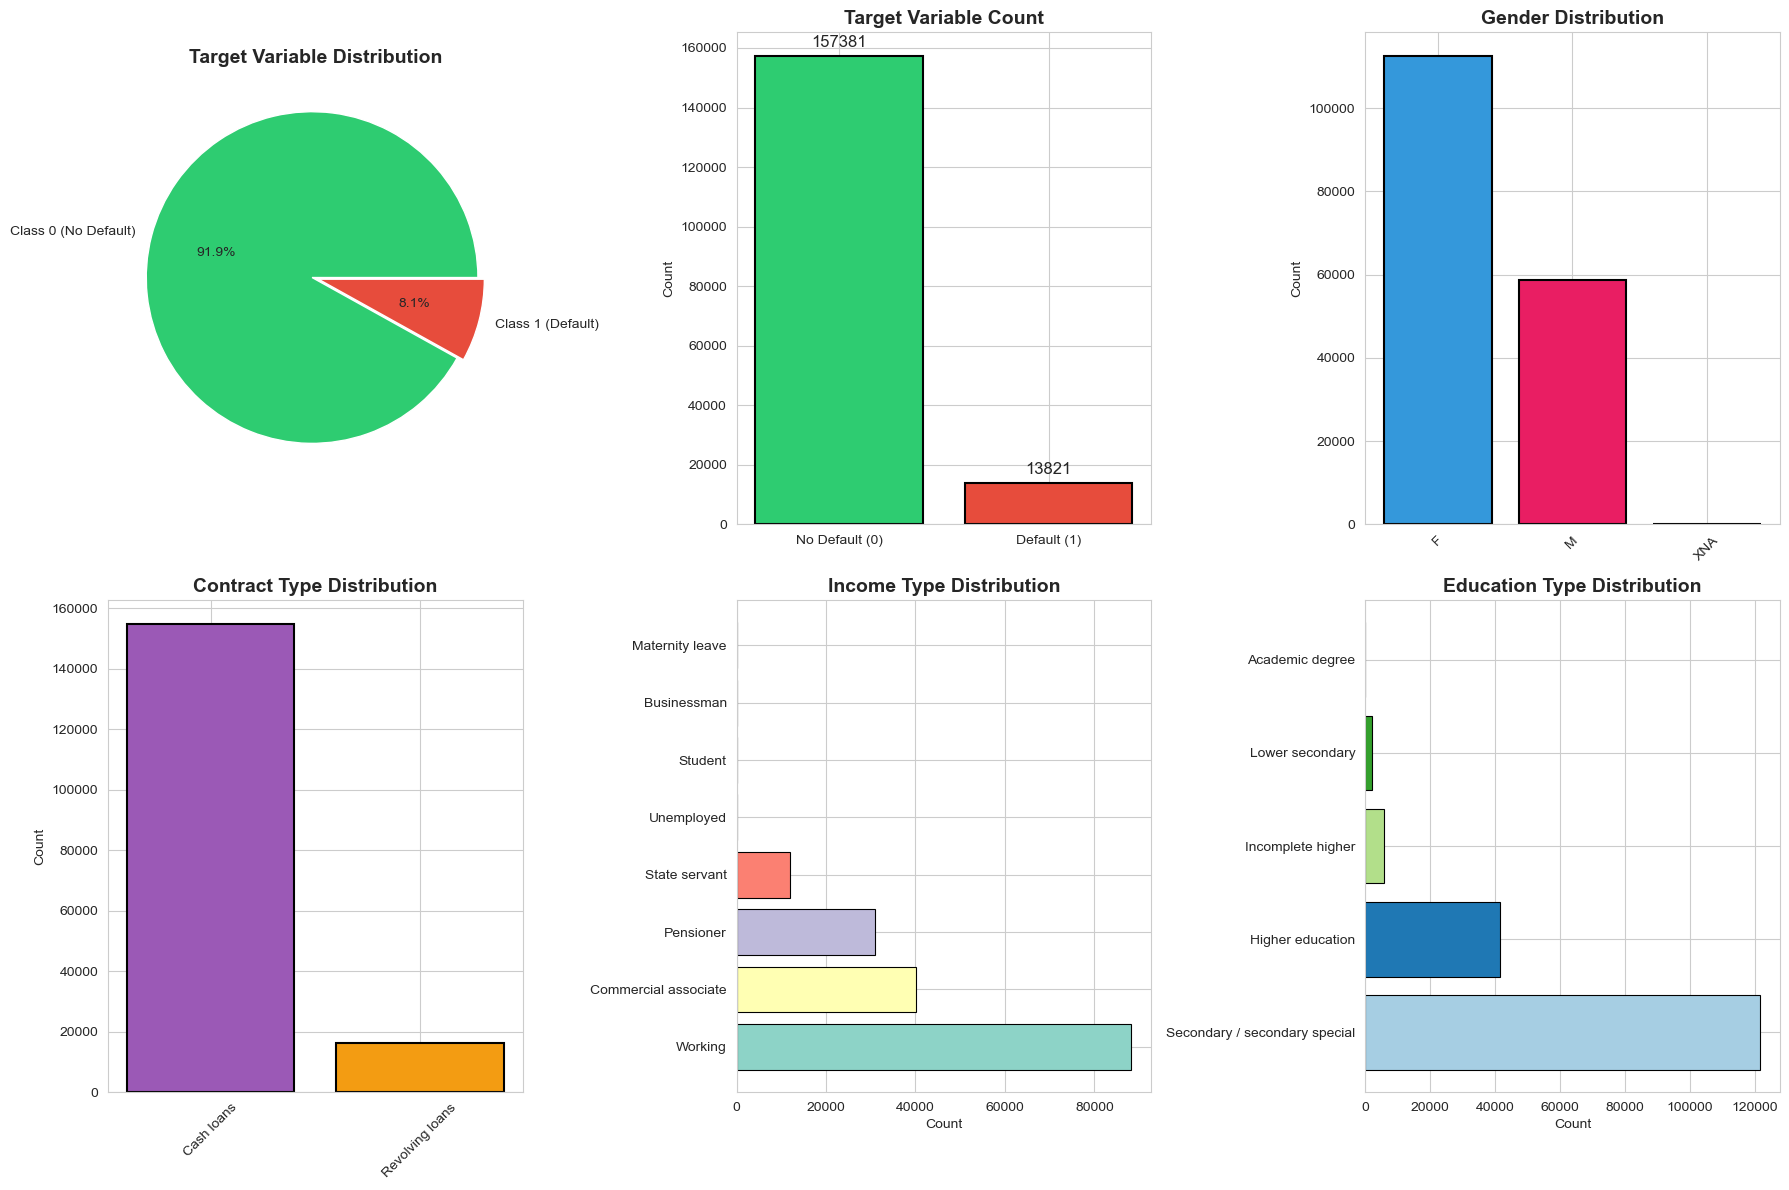


VISUALIZATION 2: Numerical Feature Distributions


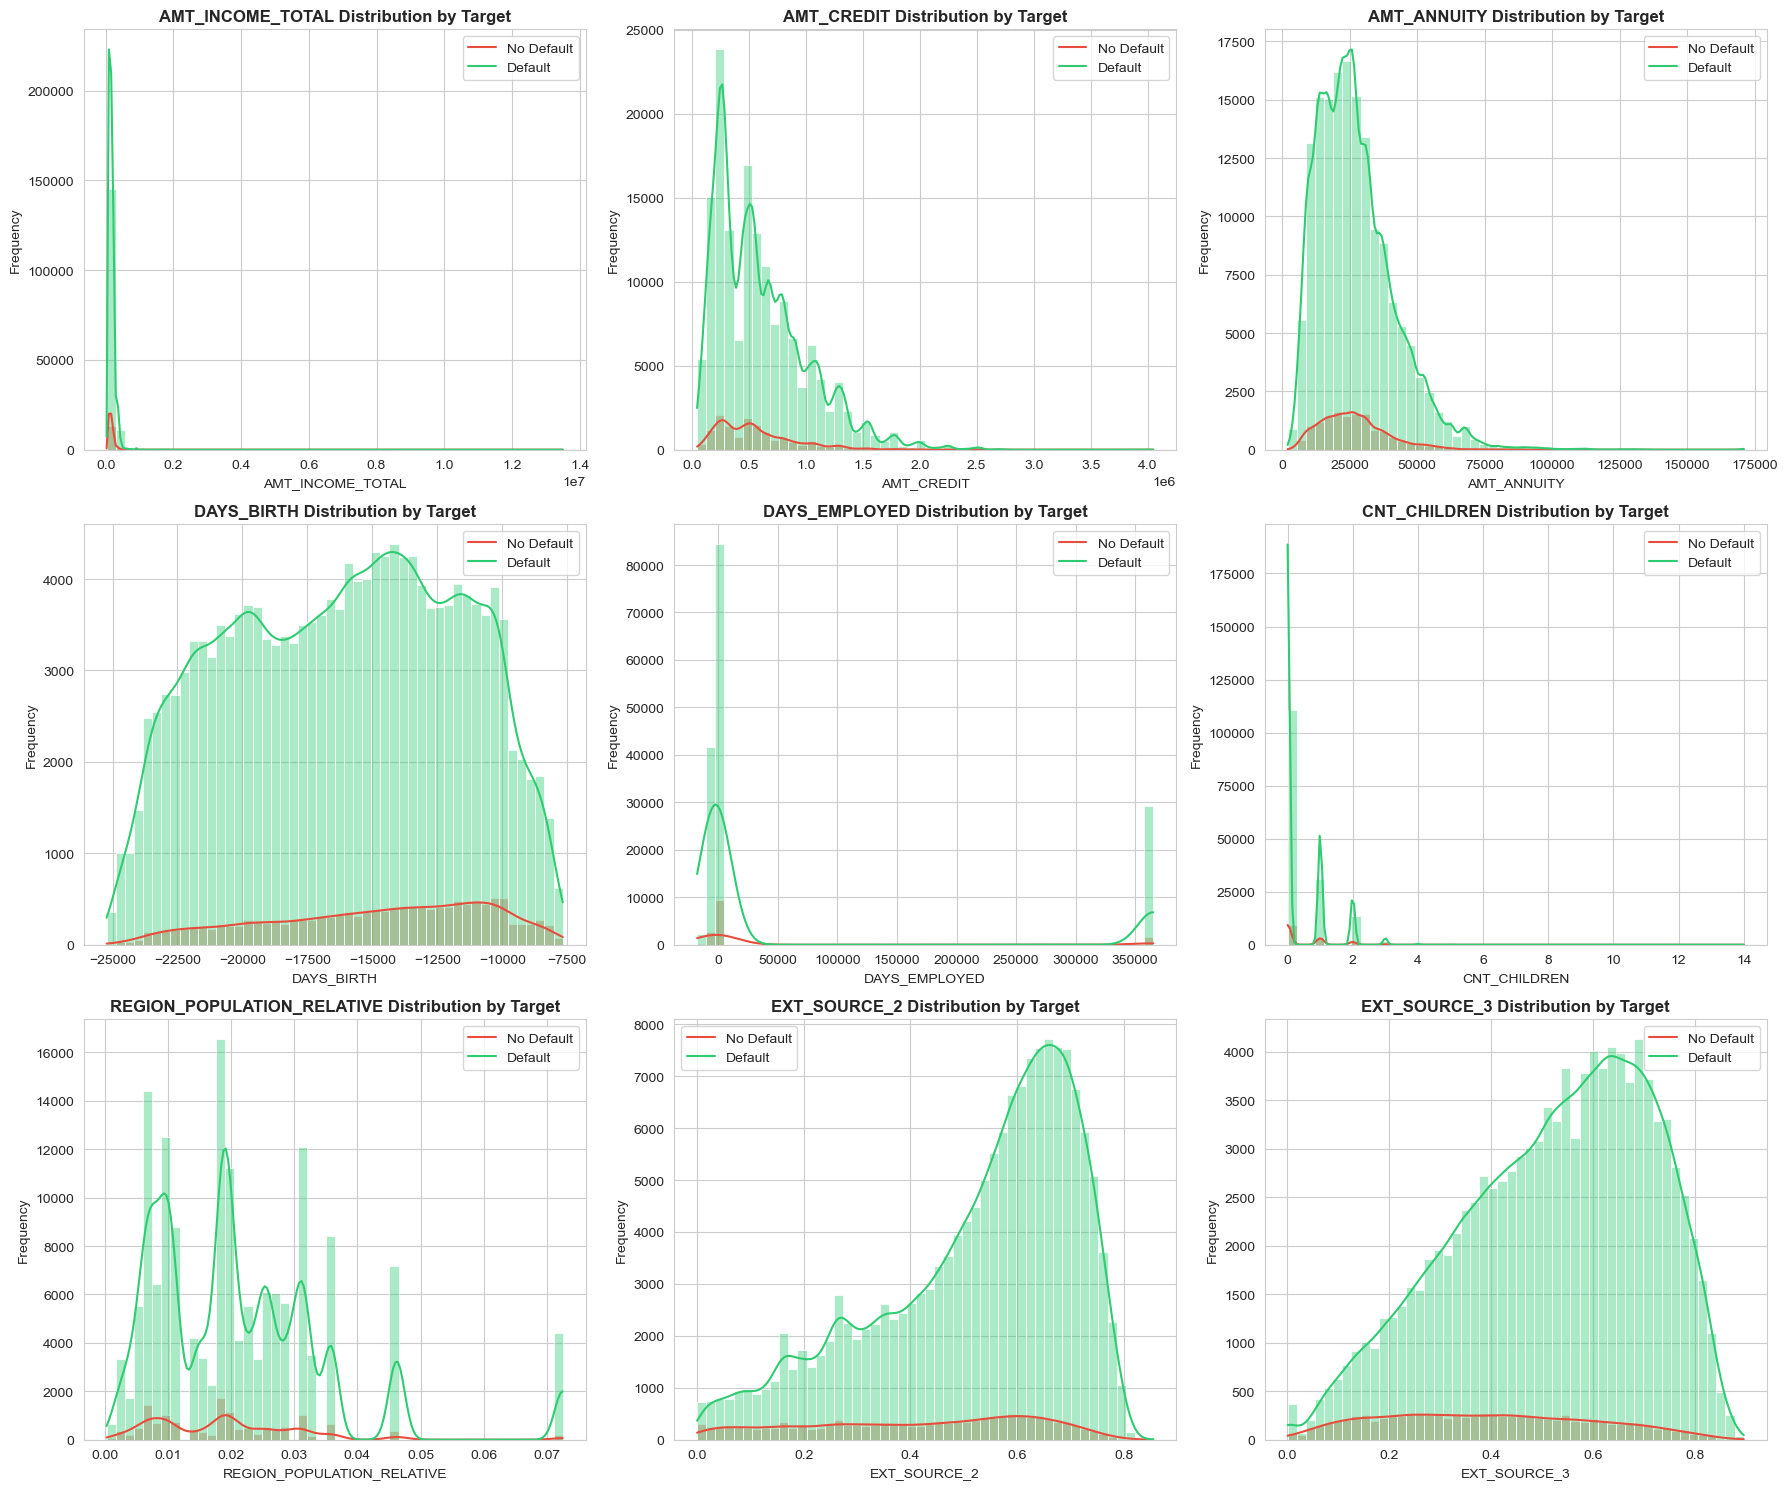


VISUALIZATION 3: Correlation Heatmap


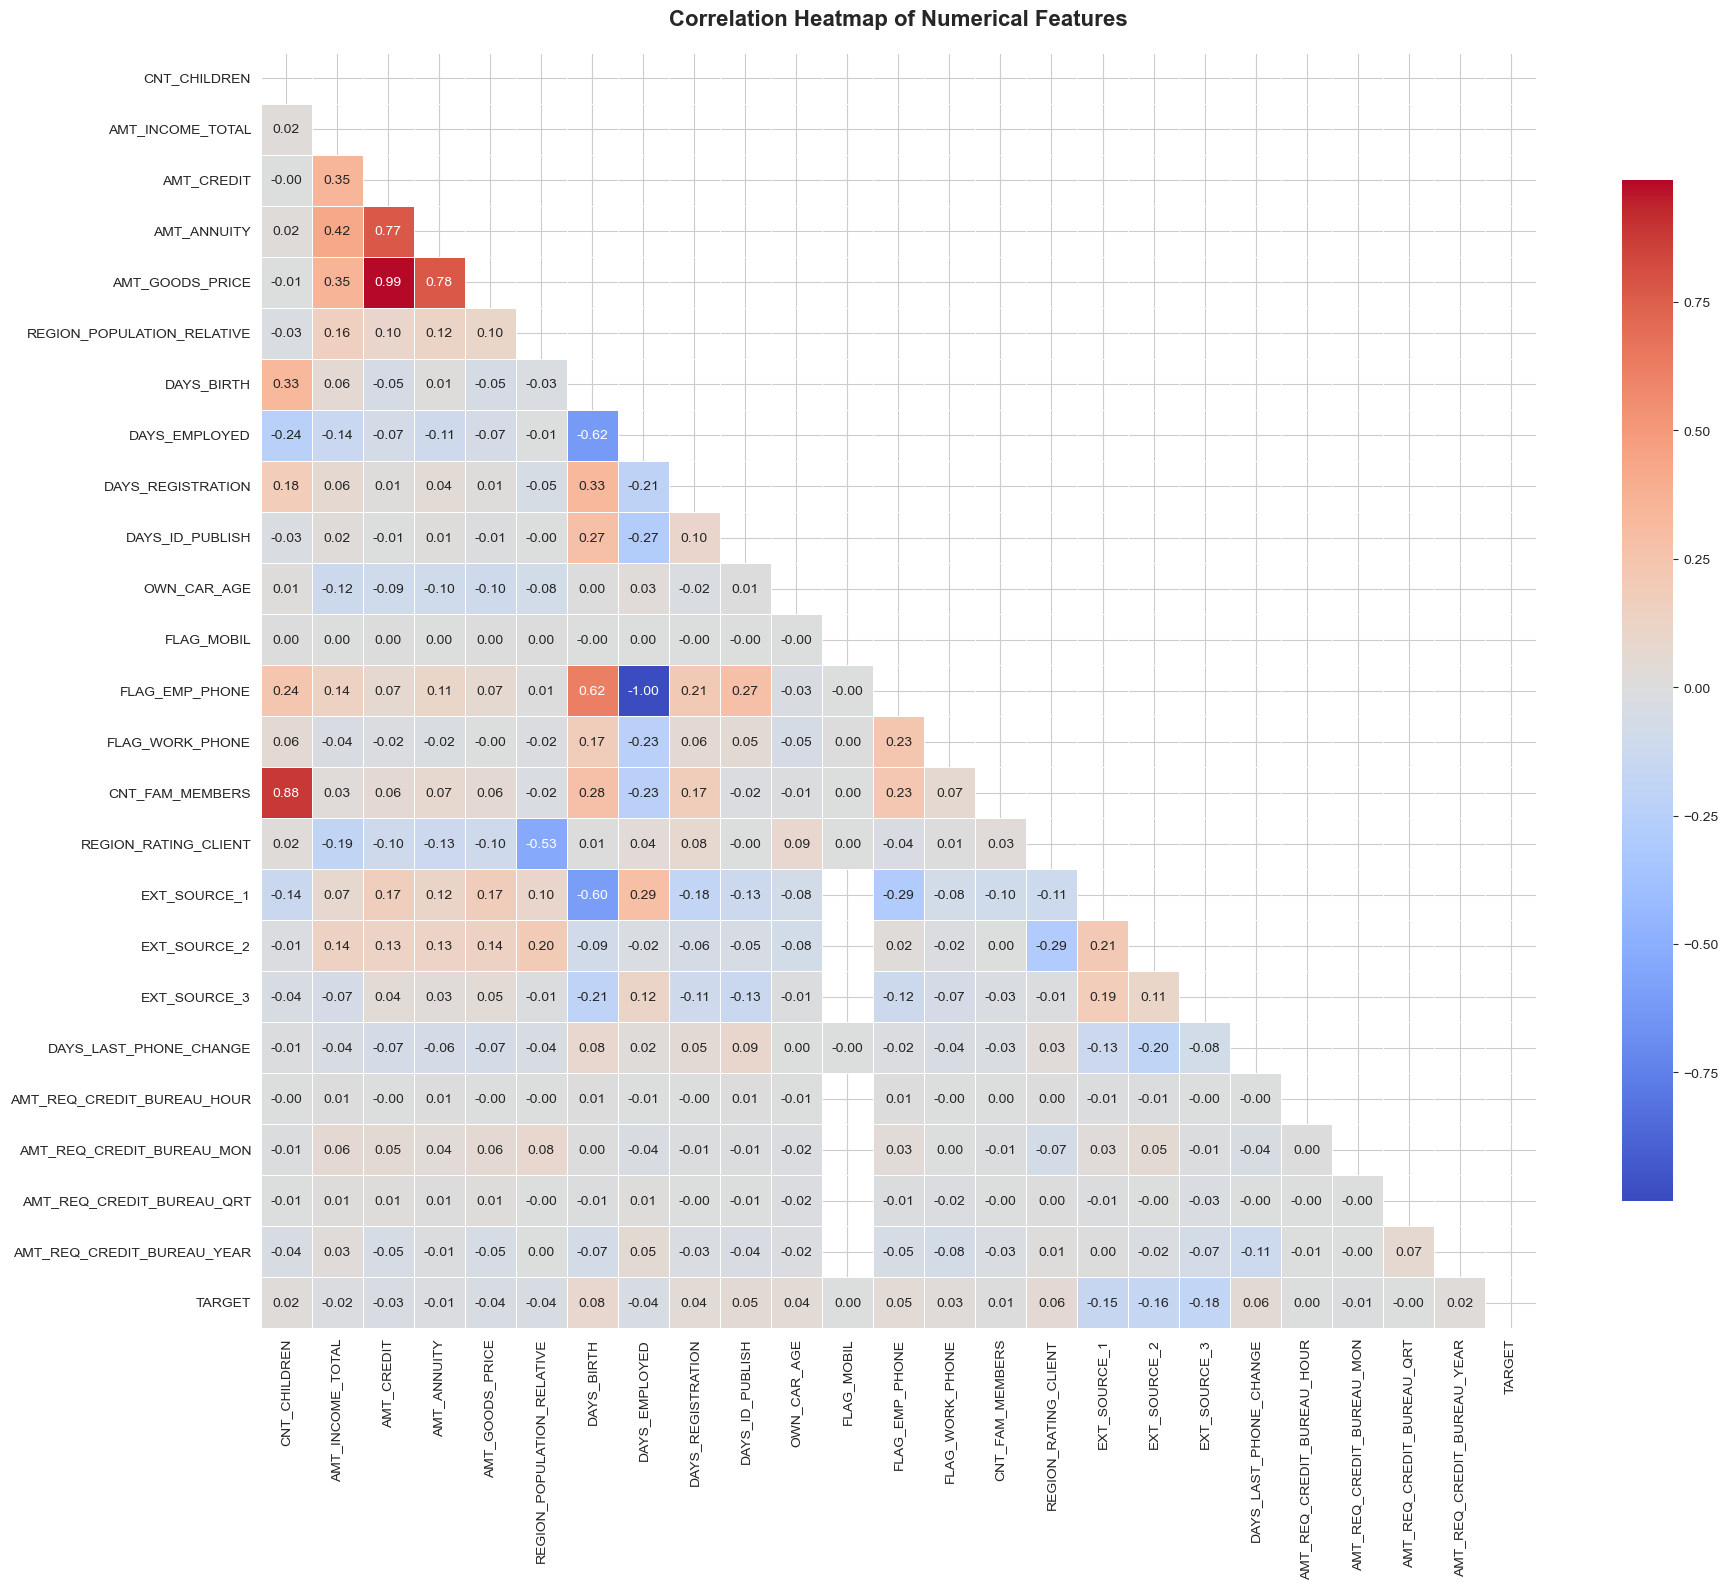


TOP 10 FEATURES CORRELATED WITH TARGET
TARGET                        1.000000
DAYS_BIRTH                    0.079541
REGION_RATING_CLIENT          0.058984
DAYS_LAST_PHONE_CHANGE        0.055194
DAYS_ID_PUBLISH               0.052567
FLAG_EMP_PHONE                0.045646
DAYS_REGISTRATION             0.041669
OWN_CAR_AGE                   0.040035
FLAG_WORK_PHONE               0.029102
AMT_REQ_CREDIT_BUREAU_YEAR    0.019691
CNT_CHILDREN                  0.018034
Name: TARGET, dtype: float64


In [4]:
print("=" * 60)
print("VISUALIZATION 1: Target Distribution")
print("=" * 60)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. Target distribution (pie chart)
axes[0, 0].pie(
    train['TARGET'].value_counts(),
    labels=['Class 0 (No Default)', 'Class 1 (Default)'],
    autopct='%1.1f%%',
    colors=['#2ecc71', '#e74c3c'],
    explode=(0.02, 0.02)
)
axes[0, 0].set_title('Target Variable Distribution', fontsize=14, fontweight='bold')

# 2. Target distribution (bar chart)
axes[0, 1].bar(
    ['No Default (0)', 'Default (1)'],
    train['TARGET'].value_counts().values,
    color=['#2ecc71', '#e74c3c'],
    edgecolor='black',
    linewidth=1.5
)
axes[0, 1].set_title('Target Variable Count', fontsize=14, fontweight='bold')
axes[0, 1].set_ylabel('Count')
for i, v in enumerate(train['TARGET'].value_counts().values):
    axes[0, 1].text(i, v + 2000, str(v), ha='center', va='bottom', fontsize=12)

# 3. Gender distribution
gender_dist = train['CODE_GENDER'].value_counts()
axes[0, 2].bar(
    gender_dist.index,
    gender_dist.values,
    color=['#3498db', '#e91e63', '#95a5a6'],
    edgecolor='black',
    linewidth=1.5
)
axes[0, 2].set_title('Gender Distribution', fontsize=14, fontweight='bold')
axes[0, 2].set_ylabel('Count')
axes[0, 2].tick_params(axis='x', rotation=45)

# 4. Contract type distribution
contract_dist = train['NAME_CONTRACT_TYPE'].value_counts()
axes[1, 0].bar(
    contract_dist.index,
    contract_dist.values,
    color=['#9b59b6', '#f39c12'],
    edgecolor='black',
    linewidth=1.5
)
axes[1, 0].set_title('Contract Type Distribution', fontsize=14, fontweight='bold')
axes[1, 0].set_ylabel('Count')
axes[1, 0].tick_params(axis='x', rotation=45)

# 5. Income type distribution
income_dist = train['NAME_INCOME_TYPE'].value_counts()
axes[1, 1].barh(
    income_dist.index,
    income_dist.values,
    color=plt.cm.Set3(range(len(income_dist))),
    edgecolor='black',
    linewidth=0.8
)
axes[1, 1].set_title('Income Type Distribution', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Count')

# 6. Education type distribution
edu_dist = train['NAME_EDUCATION_TYPE'].value_counts()
axes[1, 2].barh(
    edu_dist.index,
    edu_dist.values,
    color=plt.cm.Paired(range(len(edu_dist))),
    edgecolor='black',
    linewidth=0.8
)
axes[1, 2].set_title('Education Type Distribution', fontsize=14, fontweight='bold')
axes[1, 2].set_xlabel('Count')

plt.tight_layout()
plt.savefig('eda_categorical_features.png', dpi=300, bbox_inches='tight')
plt.show()

# Additional numerical feature visualizations
print("\n" + "=" * 60)
print("VISUALIZATION 2: Numerical Feature Distributions")
print("=" * 60)

fig, axes = plt.subplots(3, 3, figsize=(18, 15))

numerical_cols = [
    'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY',
    'DAYS_BIRTH', 'DAYS_EMPLOYED', 'CNT_CHILDREN',
    'REGION_POPULATION_RELATIVE', 'EXT_SOURCE_2', 'EXT_SOURCE_3'
]

for idx, col in enumerate(numerical_cols):
    row = idx // 3
    col_idx = idx % 3
    
    # Histogram with KDE
    sns.histplot(
        data=train,
        x=col,
        hue='TARGET',
        kde=True,
        alpha=0.4,
        ax=axes[row, col_idx],
        palette=['#2ecc71', '#e74c3c'],
        bins=50
    )
    axes[row, col_idx].set_title(f'{col} Distribution by Target', fontsize=12, fontweight='bold')
    axes[row, col_idx].set_xlabel(col)
    axes[row, col_idx].set_ylabel('Frequency')
    axes[row, col_idx].legend(['No Default', 'Default'], loc='best')

plt.tight_layout()
plt.savefig('eda_numerical_features.png', dpi=300, bbox_inches='tight')
plt.show()

# Correlation heatmap
print("\n" + "=" * 60)
print("VISUALIZATION 3: Correlation Heatmap")
print("=" * 60)

# Select numerical columns for correlation
numerical_for_corr = train.select_dtypes(include=[np.number]).columns.tolist()
numerical_for_corr.remove('SK_ID_CURR')  # Remove ID

plt.figure(figsize=(20, 16))
corr_matrix = train[numerical_for_corr].corr()

# Create mask for upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    square=True,
    cbar_kws={'shrink': 0.8}
)
plt.title('Correlation Heatmap of Numerical Features', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

# Print top correlations with TARGET
print("\n" + "=" * 60)
print("TOP 10 FEATURES CORRELATED WITH TARGET")
print("=" * 60)
target_corr = train[numerical_for_corr].corr()['TARGET'].sort_values(ascending=False)
print(target_corr.head(11))  # First is TARGET itself

feature engineering

In [5]:
def create_features(df):
    data = df.copy()

    # Convert negative time variables into more interpretable positive values.
    # DAYS_EMPLOYED = 365243 is a known placeholder for some unemployed/pensioner records.
    data["AGE_YEARS"] = (-data["DAYS_BIRTH"] / 365.25).clip(lower=0)

    data["EMPLOYED_YEARS"] = (
        -data["DAYS_EMPLOYED"].where(data["DAYS_EMPLOYED"] != 365243, np.nan)
        / 365.25
    ).clip(lower=0)

    data["REGISTRATION_YEARS"] = (-data["DAYS_REGISTRATION"] / 365.25).clip(lower=0)
    data["ID_PUBLISH_YEARS"] = (-data["DAYS_ID_PUBLISH"] / 365.25).clip(lower=0)
    data["PHONE_CHANGE_YEARS"] = (-data["DAYS_LAST_PHONE_CHANGE"] / 365.25).clip(lower=0)

    # Ratios related to credit and income
    data["CREDIT_INCOME_RATIO"] = (
        data["AMT_CREDIT"] / data["AMT_INCOME_TOTAL"].replace(0, np.nan)
    )

    data["ANNUITY_INCOME_RATIO"] = (
        data["AMT_ANNUITY"] / data["AMT_INCOME_TOTAL"].replace(0, np.nan)
    )

    data["CREDIT_ANNUITY_RATIO"] = (
        data["AMT_CREDIT"] / data["AMT_ANNUITY"].replace(0, np.nan)
    )

    data["GOODS_CREDIT_RATIO"] = (
        data["AMT_GOODS_PRICE"] / data["AMT_CREDIT"].replace(0, np.nan)
    )

    data["INCOME_PER_FAMILY_MEMBER"] = (
        data["AMT_INCOME_TOTAL"] / data["CNT_FAM_MEMBERS"].replace(0, np.nan)
    )

    data["INCOME_PER_CHILD"] = (
        data["AMT_INCOME_TOTAL"] / (data["CNT_CHILDREN"] + 1)
    )

    data["CREDIT_PER_FAMILY_MEMBER"] = (
        data["AMT_CREDIT"] / data["CNT_FAM_MEMBERS"].replace(0, np.nan)
    )

    # Family and household features
    data["CHILDREN_PER_FAMILY_MEMBER"] = (
        data["CNT_CHILDREN"] / data["CNT_FAM_MEMBERS"].replace(0, np.nan)
    )

    data["IS_PARENT"] = (data["CNT_CHILDREN"] > 0).astype("int8")
    data["IS_LARGE_FAMILY"] = (data["CNT_FAM_MEMBERS"] >= 4).astype("int8")

    # Employment and age interactions
    data["EMPLOYED_AGE_RATIO"] = (
        data["EMPLOYED_YEARS"] / data["AGE_YEARS"].replace(0, np.nan)
    )

    data["YEARS_BEFORE_RETIREMENT_APPROX"] = (
        data["AGE_YEARS"] - data["EMPLOYED_YEARS"]
    )

    data["IS_UNEMPLOYED_PLACEHOLDER"] = (
        df["DAYS_EMPLOYED"] == 365243
    ).astype("int8")

    # External-source aggregate features
    external_cols = ["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]

    data["EXT_SOURCE_MEAN"] = data[external_cols].mean(axis=1)
    data["EXT_SOURCE_MIN"] = data[external_cols].min(axis=1)
    data["EXT_SOURCE_MAX"] = data[external_cols].max(axis=1)
    data["EXT_SOURCE_STD"] = data[external_cols].std(axis=1)
    data["EXT_SOURCE_COUNT"] = data[external_cols].notna().sum(axis=1)

    # Missing-value indicators
    for col in df.columns:
        if data[col].isna().any():
            data[f"{col}_MISSING"] = data[col].isna().astype("int8")

    # Credit-bureau enquiry aggregate
    bureau_cols = [
        "AMT_REQ_CREDIT_BUREAU_HOUR",
        "AMT_REQ_CREDIT_BUREAU_MON",
        "AMT_REQ_CREDIT_BUREAU_QRT",
        "AMT_REQ_CREDIT_BUREAU_YEAR",
    ]

    data["CREDIT_BUREAU_REQUEST_TOTAL"] = data[bureau_cols].sum(axis=1, min_count=1)
    data["CREDIT_BUREAU_REQUEST_AVG"] = data[bureau_cols].mean(axis=1)
    data["CREDIT_BUREAU_REQUEST_MISSING"] = data[bureau_cols].isna().all(axis=1).astype("int8")

    # Phone/contact indicators
    data["TOTAL_CONTACT_FLAGS"] = data[
        ["FLAG_MOBIL", "FLAG_EMP_PHONE", "FLAG_WORK_PHONE"]
    ].sum(axis=1)

    # Remove the ID from modelling later, but keep it in the data for now.
    return data.replace([np.inf, -np.inf], np.nan)


train_fe = create_features(train)
test_fe = create_features(test)

print("Original train shape:", train.shape)
print("Engineered train shape:", train_fe.shape)
print("Original test shape:", test.shape)
print("Engineered test shape:", test_fe.shape)

print("\nNew engineered columns:")
new_columns = [col for col in train_fe.columns if col not in train.columns]
print(new_columns)

print("\nSample engineered features:")
display(
    train_fe[
        [
            "AGE_YEARS",
            "EMPLOYED_YEARS",
            "CREDIT_INCOME_RATIO",
            "ANNUITY_INCOME_RATIO",
            "EXT_SOURCE_MEAN",
            "EXT_SOURCE_MIN",
            "EXT_SOURCE_COUNT",
            "IS_UNEMPLOYED_PLACEHOLDER",
        ]
    ].head()
)

print("\nInfinite values remaining:")
print(np.isinf(train_fe.select_dtypes(include=np.number)).sum().sum())

Original train shape: (171202, 34)
Engineered train shape: (171202, 70)
Original test shape: (61500, 33)
Engineered test shape: (61500, 68)

New engineered columns:
['AGE_YEARS', 'EMPLOYED_YEARS', 'REGISTRATION_YEARS', 'ID_PUBLISH_YEARS', 'PHONE_CHANGE_YEARS', 'CREDIT_INCOME_RATIO', 'ANNUITY_INCOME_RATIO', 'CREDIT_ANNUITY_RATIO', 'GOODS_CREDIT_RATIO', 'INCOME_PER_FAMILY_MEMBER', 'INCOME_PER_CHILD', 'CREDIT_PER_FAMILY_MEMBER', 'CHILDREN_PER_FAMILY_MEMBER', 'IS_PARENT', 'IS_LARGE_FAMILY', 'EMPLOYED_AGE_RATIO', 'YEARS_BEFORE_RETIREMENT_APPROX', 'IS_UNEMPLOYED_PLACEHOLDER', 'EXT_SOURCE_MEAN', 'EXT_SOURCE_MIN', 'EXT_SOURCE_MAX', 'EXT_SOURCE_STD', 'EXT_SOURCE_COUNT', 'OWN_CAR_AGE_MISSING', 'CNT_FAM_MEMBERS_MISSING', 'EXT_SOURCE_1_MISSING', 'EXT_SOURCE_2_MISSING', 'EXT_SOURCE_3_MISSING', 'AMT_REQ_CREDIT_BUREAU_HOUR_MISSING', 'AMT_REQ_CREDIT_BUREAU_MON_MISSING', 'AMT_REQ_CREDIT_BUREAU_QRT_MISSING', 'AMT_REQ_CREDIT_BUREAU_YEAR_MISSING', 'CREDIT_BUREAU_REQUEST_TOTAL', 'CREDIT_BUREAU_REQUEST_AVG'

,AGE_YEARS,EMPLOYED_YEARS,CREDIT_INCOME_RATIO,ANNUITY_INCOME_RATIO,EXT_SOURCE_MEAN,EXT_SOURCE_MIN,EXT_SOURCE_COUNT,IS_UNEMPLOYED_PLACEHOLDER
0,25.278576,2.403833,6.712800,0.322920,0.372591,0.372591,1,0
1,55.162218,NaN,2.600000,0.075080,0.501366,0.449567,2,1
2,50.639288,1.431896,6.188000,0.338083,0.569503,0.569503,1,0
3,66.193018,NaN,2.264000,0.131867,0.436379,0.105235,2,1
4,29.253936,1.908282,1.721057,0.136800,0.404630,0.202490,3,0



Infinite values remaining:
0


train-validation split & preprocessing

In [8]:
# Align features, split data, and create preprocessing pipeline

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# 1. Align engineered train and test features
# TARGET only exists in the training dataset, so exclude it when matching columns.
train_feature_columns = [
    col for col in train_fe.columns
    if col not in ["TARGET", "SK_ID_CURR"]
]

test_feature_columns = [
    col for col in test_fe.columns
    if col != "SK_ID_CURR"
]

only_in_train = sorted(set(train_feature_columns) - set(test_feature_columns))
only_in_test = sorted(set(test_feature_columns) - set(train_feature_columns))

print("Features only in train:", only_in_train)
print("Features only in test:", only_in_test)

# Add any training-only feature to test with zeros.
# For example: CNT_FAM_MEMBERS_MISSING is 0 for all test rows.
for col in only_in_train:
    test_fe[col] = 0

# Add any test-only feature to train if one exists.
for col in only_in_test:
    train_fe[col] = 0

# Build feature matrices with exactly the same feature names and order.
X = train_fe.drop(columns=["TARGET", "SK_ID_CURR"])
X_test = test_fe.drop(columns=["SK_ID_CURR"])

# Explicitly arrange test columns in precisely the same order as X columns.
X_test = X_test.reindex(columns=X.columns, fill_value=0)

# Final safety checks
assert list(X.columns) == list(X_test.columns), (
    "Train and test features are still not aligned."
)

assert X.shape[1] == X_test.shape[1], (
    "Train and test feature counts do not match."
)

print("\nFeature alignment successful.")
print("Number of modelling features:", X.shape[1])

# 2. Separate target and create a stratified split
target = train_fe["TARGET"].astype("int8")

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    target,
    test_size=0.20,
    random_state=42,
    stratify=target
)

print("\nTraining shape:", X_train.shape)
print("Validation shape:", X_valid.shape)
print("Test shape:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True).sort_index())

print("\nValidation target distribution:")
print(y_valid.value_counts(normalize=True).sort_index())

# 3. Identify numerical and categorical features
numeric_features = X_train.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("\nNumber of numerical features:", len(numeric_features))
print("Number of categorical features:", len(categorical_features))

print("\nCategorical features:")
print(categorical_features)

# 4. Build preprocessing pipeline
# Numeric columns:
# - Replace missing values with the median
# - Scale values for Logistic Regression
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

# Categorical columns:
# - Replace missing categories with the most common category
# - One-hot encode text categories into numerical values
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                min_frequency=10,
                sparse_output=True,
            ),
        ),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    remainder="drop",
)

print("\nPreprocessor created successfully.")

Features only in train: ['CNT_FAM_MEMBERS_MISSING']
Features only in test: []

Feature alignment successful.
Number of modelling features: 68

Training shape: (136961, 68)
Validation shape: (34241, 68)
Test shape: (61500, 68)

Training target distribution:
TARGET
0    0.919269
1    0.080731
Name: proportion, dtype: float64

Validation target distribution:
TARGET
0    0.919278
1    0.080722
Name: proportion, dtype: float64

Number of numerical features: 60
Number of categorical features: 8

Categorical features:
['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'ORGANIZATION_TYPE']

Preprocessor created successfully.


logistic regression baseline

Training Logistic Regression model...

LOGISTIC REGRESSION RESULTS
Training ROC-AUC:   0.744525
Validation ROC-AUC: 0.735366
Overfitting gap:    0.009159

Classification report at threshold = 0.50:
              precision    recall  f1-score   support

           0     0.9571    0.6839    0.7978     31477
           1     0.1531    0.6509    0.2479      2764

    accuracy                         0.6813     34241
   macro avg     0.5551    0.6674    0.5229     34241
weighted avg     0.8922    0.6813    0.7534     34241

Confusion matrix at threshold = 0.50:
[[21528  9949]
 [  965  1799]]


<Figure size 800x600 with 0 Axes>

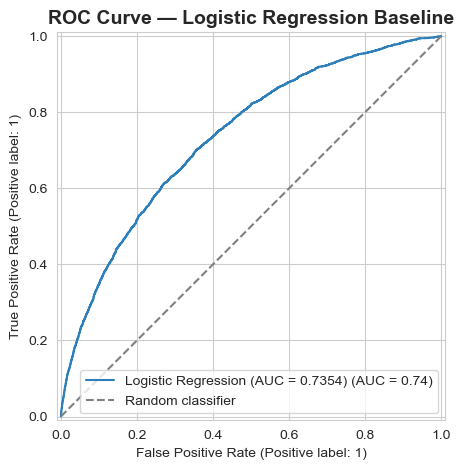

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, RocCurveDisplay

# Pipeline:
# 1. Apply numeric/categorical preprocessing
# 2. Fit Logistic Regression
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            LogisticRegression(
                max_iter=2000,
                solver="saga",
                class_weight="balanced",
                C=1.0,
                random_state=42,
                n_jobs=-1,
            ),
        ),
    ]
)

print("Training Logistic Regression model...")

logistic_model.fit(X_train, y_train)

# Predicted probabilities are required for ROC-AUC.
# [:, 1] gives probability of class 1 = payment difficulty/default.
train_pred_proba_lr = logistic_model.predict_proba(X_train)[:, 1]
valid_pred_proba_lr = logistic_model.predict_proba(X_valid)[:, 1]

# ROC-AUC scores
train_auc_lr = roc_auc_score(y_train, train_pred_proba_lr)
valid_auc_lr = roc_auc_score(y_valid, valid_pred_proba_lr)

print("\n" + "=" * 60)
print("LOGISTIC REGRESSION RESULTS")
print("=" * 60)
print(f"Training ROC-AUC:   {train_auc_lr:.6f}")
print(f"Validation ROC-AUC: {valid_auc_lr:.6f}")
print(f"Overfitting gap:    {train_auc_lr - valid_auc_lr:.6f}")

# Default classification at threshold 0.50.
# This is secondary: ROC-AUC, not classification accuracy, is the competition metric.
valid_pred_lr = (valid_pred_proba_lr >= 0.50).astype(int)

print("\nClassification report at threshold = 0.50:")
print(classification_report(y_valid, valid_pred_lr, digits=4))

print("Confusion matrix at threshold = 0.50:")
cm_lr = confusion_matrix(y_valid, valid_pred_lr)
print(cm_lr)

# ROC curve visualization
plt.figure(figsize=(8, 6))
RocCurveDisplay.from_predictions(
    y_valid,
    valid_pred_proba_lr,
    name=f"Logistic Regression (AUC = {valid_auc_lr:.4f})",
    color="#2c7fb8",
)
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random classifier")
plt.title("ROC Curve — Logistic Regression Baseline", fontsize=14, fontweight="bold")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("roc_curve_logistic_regression.png", dpi=300, bbox_inches="tight")
plt.show()

random forest model

Training Random Forest model...

RANDOM FOREST RESULTS
Training ROC-AUC:   0.866864
Validation ROC-AUC: 0.739844
Overfitting gap:    0.127019

MODEL COMPARISON
Logistic Regression validation AUC: 0.735366
Random Forest validation AUC:      0.739844
Difference:                         +0.004478


<Figure size 900x700 with 0 Axes>

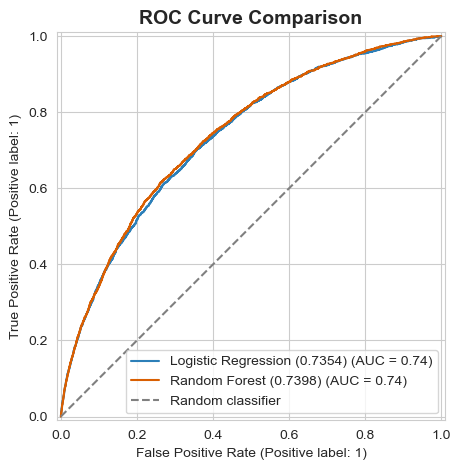

In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, RocCurveDisplay

# Random Forest does not require StandardScaler.
# Still need to impute missing values and encode categorical variables.
numeric_transformer_rf = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
    ]
)

categorical_transformer_rf = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                min_frequency=10,
                sparse_output=False,
            ),
        ),
    ]
)

preprocessor_rf = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_rf, numeric_features),
        ("cat", categorical_transformer_rf, categorical_features),
    ],
    remainder="drop",
)

random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor_rf),
        (
            "model",
            RandomForestClassifier(
                n_estimators=300,
                max_depth=12,
                min_samples_leaf=10,
                max_features="sqrt",
                class_weight="balanced_subsample",
                random_state=42,
                n_jobs=-1,
            ),
        ),
    ]
)

print("Training Random Forest model...")
random_forest_model.fit(X_train, y_train)

# Predicted probabilities
train_pred_proba_rf = random_forest_model.predict_proba(X_train)[:, 1]
valid_pred_proba_rf = random_forest_model.predict_proba(X_valid)[:, 1]

# ROC-AUC
train_auc_rf = roc_auc_score(y_train, train_pred_proba_rf)
valid_auc_rf = roc_auc_score(y_valid, valid_pred_proba_rf)

print("\n" + "=" * 60)
print("RANDOM FOREST RESULTS")
print("=" * 60)
print(f"Training ROC-AUC:   {train_auc_rf:.6f}")
print(f"Validation ROC-AUC: {valid_auc_rf:.6f}")
print(f"Overfitting gap:    {train_auc_rf - valid_auc_rf:.6f}")

# Compare with Logistic Regression
print("\n" + "=" * 60)
print("MODEL COMPARISON")
print("=" * 60)
print(f"Logistic Regression validation AUC: {valid_auc_lr:.6f}")
print(f"Random Forest validation AUC:      {valid_auc_rf:.6f}")
print(f"Difference:                         {valid_auc_rf - valid_auc_lr:+.6f}")

# ROC curve comparison
plt.figure(figsize=(9, 7))

RocCurveDisplay.from_predictions(
    y_valid,
    valid_pred_proba_lr,
    name=f"Logistic Regression ({valid_auc_lr:.4f})",
    color="#2c7fb8",
)

RocCurveDisplay.from_predictions(
    y_valid,
    valid_pred_proba_rf,
    name=f"Random Forest ({valid_auc_rf:.4f})",
    color="#d95f02",
    ax=plt.gca(),
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray",
    label="Random classifier",
)

plt.title("ROC Curve Comparison", fontsize=14, fontweight="bold")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("roc_curve_model_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

check boosting libraries

In [ ]:
import importlib.util

available_libraries = {
    "lightgbm": importlib.util.find_spec("lightgbm") is not None,
    "xgboost": importlib.util.find_spec("xgboost") is not None,
    "catboost": importlib.util.find_spec("catboost") is not None,
}

print("Available boosting libraries:")
for library, available in available_libraries.items():
    print(f"{library}: {available}")

Available boosting libraries:
lightgbm: True
xgboost: True
catboost: True


CatBoost Gradient-Boosting Model

Categorical feature indices: [0, 1, 7, 8, 9, 10, 20, 23]
Number of categorical features: 8

Training CatBoost model...
0:	test: 0.6395606	best: 0.6395606 (0)	total: 347ms	remaining: 8m 40s
100:	test: 0.7378785	best: 0.7378785 (100)	total: 19.5s	remaining: 4m 30s
200:	test: 0.7461473	best: 0.7461473 (200)	total: 36.1s	remaining: 3m 53s
300:	test: 0.7495782	best: 0.7495782 (300)	total: 52.6s	remaining: 3m 29s
400:	test: 0.7516422	best: 0.7516422 (400)	total: 1m 9s	remaining: 3m 9s
500:	test: 0.7536576	best: 0.7536576 (500)	total: 1m 27s	remaining: 2m 54s
600:	test: 0.7544958	best: 0.7545132 (590)	total: 1m 50s	remaining: 2m 45s
700:	test: 0.7551895	best: 0.7551910 (697)	total: 2m 11s	remaining: 2m 29s
800:	test: 0.7554575	best: 0.7554575 (800)	total: 2m 30s	remaining: 2m 11s
900:	test: 0.7558131	best: 0.7558346 (899)	total: 2m 50s	remaining: 1m 53s
1000:	test: 0.7559677	best: 0.7560042 (996)	total: 3m 9s	remaining: 1m 34s
1100:	test: 0.7560207	best: 0.7562437 (1063)	total: 3m 29s	remaini

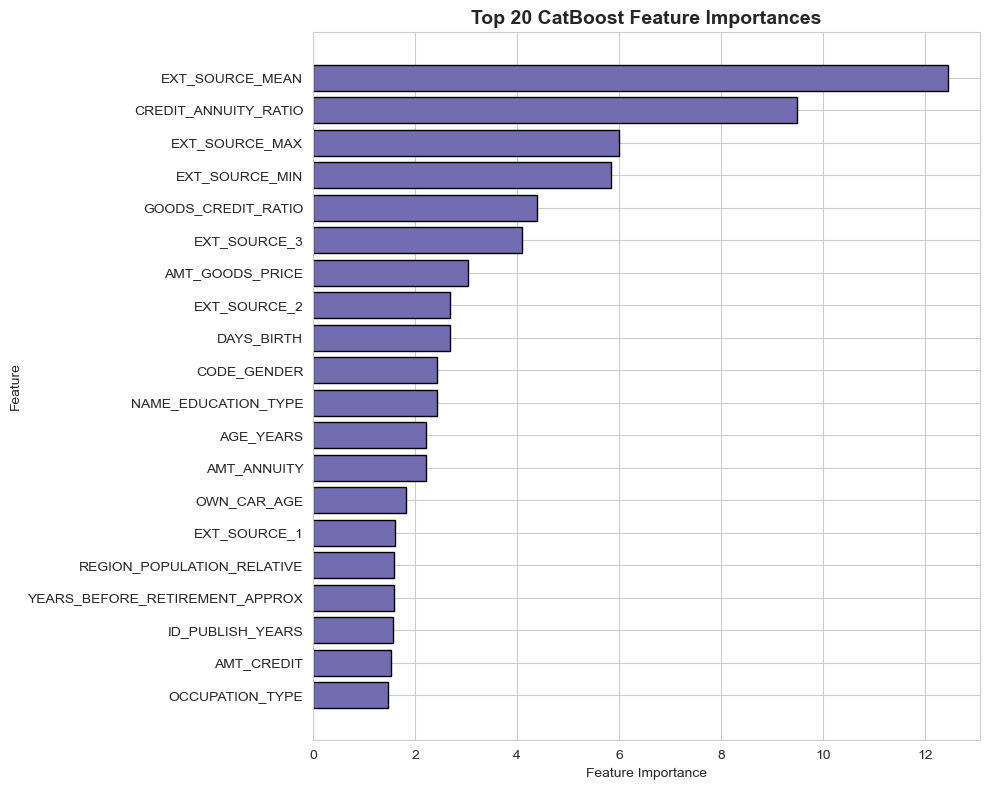

<Figure size 1000x800 with 0 Axes>

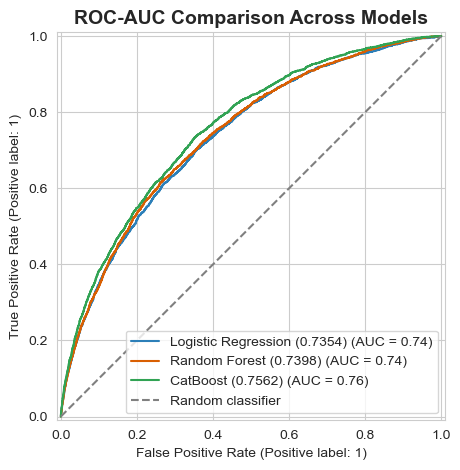

In [12]:
from catboost import CatBoostClassifier
from sklearn.metrics import roc_auc_score, RocCurveDisplay

# Create CatBoost-specific copies of the split data.
# CatBoost needs categorical columns as strings.
X_train_cb = X_train.copy()
X_valid_cb = X_valid.copy()
X_test_cb = X_test.copy()

# Replace missing categorical values and convert all categorical columns to strings.
for col in categorical_features:
    X_train_cb[col] = X_train_cb[col].fillna("MISSING").astype(str)
    X_valid_cb[col] = X_valid_cb[col].fillna("MISSING").astype(str)
    X_test_cb[col] = X_test_cb[col].fillna("MISSING").astype(str)

# CatBoost can receive categorical column names directly.
cat_feature_indices = [
    X_train_cb.columns.get_loc(col)
    for col in categorical_features
]

print("Categorical feature indices:", cat_feature_indices)
print("Number of categorical features:", len(cat_feature_indices))

# The loss function Logloss is suitable for binary classification.
# eval_metric AUC tells CatBoost to monitor ROC-AUC on the validation data.
catboost_model = CatBoostClassifier(
    iterations=1500,
    learning_rate=0.03,
    depth=6,
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=42,
    l2_leaf_reg=5,
    random_strength=1,
    border_count=128,
    verbose=100,
    thread_count=-1,
    allow_writing_files=False,
)

print("\nTraining CatBoost model...")

catboost_model.fit(
    X_train_cb,
    y_train,
    cat_features=cat_feature_indices,
    eval_set=(X_valid_cb, y_valid),
    early_stopping_rounds=150,
    verbose=100,
)

# Predict default probabilities
train_pred_proba_cb = catboost_model.predict_proba(X_train_cb)[:, 1]
valid_pred_proba_cb = catboost_model.predict_proba(X_valid_cb)[:, 1]

# Evaluate AUC
train_auc_cb = roc_auc_score(y_train, train_pred_proba_cb)
valid_auc_cb = roc_auc_score(y_valid, valid_pred_proba_cb)

print("\n" + "=" * 60)
print("CATBOOST RESULTS")
print("=" * 60)
print(f"Best iteration:      {catboost_model.get_best_iteration()}")
print(f"Training ROC-AUC:    {train_auc_cb:.6f}")
print(f"Validation ROC-AUC:  {valid_auc_cb:.6f}")
print(f"Overfitting gap:     {train_auc_cb - valid_auc_cb:.6f}")

print("\n" + "=" * 60)
print("VALIDATION AUC COMPARISON")
print("=" * 60)
print(f"Logistic Regression: {valid_auc_lr:.6f}")
print(f"Random Forest:       {valid_auc_rf:.6f}")
print(f"CatBoost:            {valid_auc_cb:.6f}")

# Feature importance
feature_importance_cb = pd.DataFrame(
    {
        "feature": X_train_cb.columns,
        "importance": catboost_model.get_feature_importance(),
    }
).sort_values("importance", ascending=False)

print("\nTop 20 CatBoost feature importances:")
print(feature_importance_cb.head(20).to_string(index=False))

# Plot feature importance
top_features_cb = feature_importance_cb.head(20).sort_values(
    "importance",
    ascending=True
)

plt.figure(figsize=(10, 8))
plt.barh(
    top_features_cb["feature"],
    top_features_cb["importance"],
    color="#756bb1",
    edgecolor="black",
)
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 20 CatBoost Feature Importances", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("catboost_feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

# Compare all ROC curves
plt.figure(figsize=(10, 8))

RocCurveDisplay.from_predictions(
    y_valid,
    valid_pred_proba_lr,
    name=f"Logistic Regression ({valid_auc_lr:.4f})",
    color="#2c7fb8",
)

RocCurveDisplay.from_predictions(
    y_valid,
    valid_pred_proba_rf,
    name=f"Random Forest ({valid_auc_rf:.4f})",
    color="#d95f02",
    ax=plt.gca(),
)

RocCurveDisplay.from_predictions(
    y_valid,
    valid_pred_proba_cb,
    name=f"CatBoost ({valid_auc_cb:.4f})",
    color="#31a354",
    ax=plt.gca(),
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray",
    label="Random classifier",
)

plt.title("ROC-AUC Comparison Across Models", fontsize=14, fontweight="bold")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("roc_curve_all_models.png", dpi=300, bbox_inches="tight")
plt.show()

Tune CatBoost

In [13]:
from catboost import CatBoostClassifier
from sklearn.metrics import roc_auc_score

catboost_tuned_model = CatBoostClassifier(
    iterations=2500,
    learning_rate=0.02,
    depth=7,
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=42,
    l2_leaf_reg=8,
    random_strength=0.5,
    border_count=128,
    verbose=100,
    thread_count=-1,
    allow_writing_files=False,
)

print("Training tuned CatBoost model...")

catboost_tuned_model.fit(
    X_train_cb,
    y_train,
    cat_features=cat_feature_indices,
    eval_set=(X_valid_cb, y_valid),
    early_stopping_rounds=200,
    verbose=100,
)

# Generate class-1/default probabilities
train_pred_proba_cb_tuned = catboost_tuned_model.predict_proba(X_train_cb)[:, 1]
valid_pred_proba_cb_tuned = catboost_tuned_model.predict_proba(X_valid_cb)[:, 1]

# Calculate ROC-AUC scores
train_auc_cb_tuned = roc_auc_score(y_train, train_pred_proba_cb_tuned)
valid_auc_cb_tuned = roc_auc_score(y_valid, valid_pred_proba_cb_tuned)

print("\n" + "=" * 60)
print("TUNED CATBOOST RESULTS")
print("=" * 60)
print(f"Best iteration:      {catboost_tuned_model.get_best_iteration()}")
print(f"Training ROC-AUC:    {train_auc_cb_tuned:.6f}")
print(f"Validation ROC-AUC:  {valid_auc_cb_tuned:.6f}")
print(f"Overfitting gap:     {train_auc_cb_tuned - valid_auc_cb_tuned:.6f}")

print("\n" + "=" * 60)
print("CATBOOST COMPARISON")
print("=" * 60)
print(f"Initial CatBoost AUC: {valid_auc_cb:.6f}")
print(f"Tuned CatBoost AUC:   {valid_auc_cb_tuned:.6f}")
print(f"Difference:           {valid_auc_cb_tuned - valid_auc_cb:+.6f}")

# Retain the best CatBoost model and its validation probabilities.
if valid_auc_cb_tuned > valid_auc_cb:
    best_catboost_model = catboost_tuned_model
    best_valid_pred_proba_cb = valid_pred_proba_cb_tuned
    best_catboost_auc = valid_auc_cb_tuned
    best_catboost_name = "Tuned CatBoost"
else:
    best_catboost_model = catboost_model
    best_valid_pred_proba_cb = valid_pred_proba_cb
    best_catboost_auc = valid_auc_cb
    best_catboost_name = "Initial CatBoost"

print("\n" + "=" * 60)
print("BEST CATBOOST CHOICE")
print("=" * 60)
print(f"Selected model: {best_catboost_name}")
print(f"Selected validation ROC-AUC: {best_catboost_auc:.6f}")

Training tuned CatBoost model...
0:	test: 0.6648071	best: 0.6648071 (0)	total: 258ms	remaining: 10m 44s
100:	test: 0.7390349	best: 0.7390349 (100)	total: 21.2s	remaining: 8m 24s
200:	test: 0.7462489	best: 0.7462489 (200)	total: 41.4s	remaining: 7m 53s
300:	test: 0.7499707	best: 0.7499707 (300)	total: 1m 1s	remaining: 7m 28s
400:	test: 0.7521444	best: 0.7521444 (400)	total: 1m 25s	remaining: 7m 29s
500:	test: 0.7534416	best: 0.7534455 (497)	total: 1m 49s	remaining: 7m 18s
600:	test: 0.7544107	best: 0.7544133 (599)	total: 2m 13s	remaining: 7m
700:	test: 0.7551464	best: 0.7551624 (699)	total: 2m 37s	remaining: 6m 43s
800:	test: 0.7554124	best: 0.7554444 (790)	total: 3m 2s	remaining: 6m 27s
900:	test: 0.7556123	best: 0.7556371 (880)	total: 3m 25s	remaining: 6m 5s
1000:	test: 0.7558215	best: 0.7558323 (999)	total: 3m 49s	remaining: 5m 42s
1100:	test: 0.7561820	best: 0.7561820 (1100)	total: 4m 11s	remaining: 5m 19s
1200:	test: 0.7564455	best: 0.7564692 (1198)	total: 4m 37s	remaining: 5m
1300

Compare CatBoost Blend

CATBOOST VALIDATION BLEND RESULTS
 tuned_weight  initial_weight  validation_auc
          0.7             0.3        0.757087
          0.9             0.1        0.757060
          0.5             0.5        0.757001
          1.0             0.0        0.756991
          0.3             0.7        0.756799

SELECTED FINAL APPROACH
Tuned CatBoost weight:   0.7
Initial CatBoost weight: 0.3
Blended validation AUC:  0.757087
Initial CatBoost AUC:    0.756244
Tuned CatBoost AUC:      0.756991
Blend vs tuned change:   +0.000095


<Figure size 1000x800 with 0 Axes>

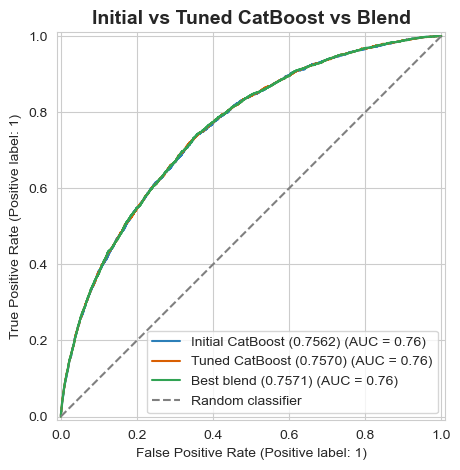

In [ ]:
# Validation blend of the two CatBoost models

from sklearn.metrics import roc_auc_score, RocCurveDisplay

# Candidate blends:
# 70% tuned + 30% initial is conservative because tuned is slightly stronger.
blend_weights = [
    (1.0, 0.0),   # Tuned only
    (0.9, 0.1),   # 90% tuned, 10% initial
    (0.7, 0.3),   # 70% tuned, 30% initial
    (0.5, 0.5),   # Equal blend
    (0.3, 0.7),   # 30% tuned, 70% initial
]

blend_results = []

for tuned_weight, initial_weight in blend_weights:
    blended_valid_proba = (
        tuned_weight * valid_pred_proba_cb_tuned
        + initial_weight * valid_pred_proba_cb
    )

    blend_auc = roc_auc_score(y_valid, blended_valid_proba)

    blend_results.append(
        {
            "tuned_weight": tuned_weight,
            "initial_weight": initial_weight,
            "validation_auc": blend_auc,
        }
    )

blend_results_df = pd.DataFrame(blend_results).sort_values(
    "validation_auc",
    ascending=False
)

print("=" * 65)
print("CATBOOST VALIDATION BLEND RESULTS")
print("=" * 65)
print(blend_results_df.to_string(index=False))

# Select the best weighting using validation AUC
best_blend = blend_results_df.iloc[0]

best_tuned_weight = best_blend["tuned_weight"]
best_initial_weight = best_blend["initial_weight"]
best_blend_auc = best_blend["validation_auc"]

best_blend_valid_proba = (
    best_tuned_weight * valid_pred_proba_cb_tuned
    + best_initial_weight * valid_pred_proba_cb
)

print("\n" + "=" * 65)
print("SELECTED FINAL APPROACH")
print("=" * 65)
print(f"Tuned CatBoost weight:   {best_tuned_weight:.1f}")
print(f"Initial CatBoost weight: {best_initial_weight:.1f}")
print(f"Blended validation AUC:  {best_blend_auc:.6f}")
print(f"Initial CatBoost AUC:    {valid_auc_cb:.6f}")
print(f"Tuned CatBoost AUC:      {valid_auc_cb_tuned:.6f}")
print(f"Blend vs tuned change:   {best_blend_auc - valid_auc_cb_tuned:+.6f}")

# ROC curve: initial vs tuned vs best blend
plt.figure(figsize=(10, 8))

RocCurveDisplay.from_predictions(
    y_valid,
    valid_pred_proba_cb,
    name=f"Initial CatBoost ({valid_auc_cb:.4f})",
    color="#2c7fb8",
)

RocCurveDisplay.from_predictions(
    y_valid,
    valid_pred_proba_cb_tuned,
    name=f"Tuned CatBoost ({valid_auc_cb_tuned:.4f})",
    color="#d95f02",
    ax=plt.gca(),
)

RocCurveDisplay.from_predictions(
    y_valid,
    best_blend_valid_proba,
    name=f"Best blend ({best_blend_auc:.4f})",
    color="#31a354",
    ax=plt.gca(),
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray",
    label="Random classifier",
)

plt.title("Initial vs Tuned CatBoost vs Blend", fontsize=14, fontweight="bold")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("roc_curve_catboost_blend.png", dpi=300, bbox_inches="tight")
plt.show()

Train Final Models and Create Submission

In [15]:
# Train final CatBoost models on all training data
# and create the final Omnicampus submission CSV.

from pathlib import Path
from catboost import CatBoostClassifier
import numpy as np
import pandas as pd

# 1. Prepare full training and test datasets for CatBoost
X_full_cb = X.copy()
X_test_cb_final = X_test.copy()
y_full = target.copy()

# CatBoost requires categorical features to be text values.
for col in categorical_features:
    X_full_cb[col] = X_full_cb[col].fillna("MISSING").astype(str)
    X_test_cb_final[col] = X_test_cb_final[col].fillna("MISSING").astype(str)

# Confirm same column order before fitting/predicting.
assert list(X_full_cb.columns) == list(X_test_cb_final.columns)

cat_feature_indices_final = [
    X_full_cb.columns.get_loc(col)
    for col in categorical_features
]

print("Full training data shape:", X_full_cb.shape)
print("Final test data shape:", X_test_cb_final.shape)
print("Categorical-feature indices:", cat_feature_indices_final)

# 2. Set final iteration counts from validation early stopping
# get_best_iteration() is zero-indexed, so add 1.
initial_iterations_final = catboost_model.get_best_iteration() + 1
tuned_iterations_final = catboost_tuned_model.get_best_iteration() + 1

print(f"\nInitial CatBoost final iterations: {initial_iterations_final}")
print(f"Tuned CatBoost final iterations:   {tuned_iterations_final}")

# 3. Train initial CatBoost configuration on all rows
final_initial_model = CatBoostClassifier(
    iterations=initial_iterations_final,
    learning_rate=0.03,
    depth=6,
    loss_function="Logloss",
    random_seed=42,
    l2_leaf_reg=5,
    random_strength=1,
    border_count=128,
    verbose=100,
    thread_count=-1,
    allow_writing_files=False,
)

print("\nTraining final initial CatBoost model on all training rows...")

final_initial_model.fit(
    X_full_cb,
    y_full,
    cat_features=cat_feature_indices_final,
    verbose=100,
)

# 4. Train tuned CatBoost configuration on all rows

final_tuned_model = CatBoostClassifier(
    iterations=tuned_iterations_final,
    learning_rate=0.02,
    depth=7,
    loss_function="Logloss",
    random_seed=42,
    l2_leaf_reg=8,
    random_strength=0.5,
    border_count=128,
    verbose=100,
    thread_count=-1,
    allow_writing_files=False,
)

print("\nTraining final tuned CatBoost model on all training rows...")

final_tuned_model.fit(
    X_full_cb,
    y_full,
    cat_features=cat_feature_indices_final,
    verbose=100,
)

# 5. Predict test probabilities and make a 70/30 blend
test_pred_initial = final_initial_model.predict_proba(X_test_cb_final)[:, 1]
test_pred_tuned = final_tuned_model.predict_proba(X_test_cb_final)[:, 1]

# Best validation blend: 70% tuned + 30% initial.
test_pred_final = (
    0.70 * test_pred_tuned
    + 0.30 * test_pred_initial
)

# 6. Build submission in the exact sample-submission schema
submission = sample_sub.copy()

# Confirm the provided sample format before replacing TARGET predictions.
print("\nSample submission columns:", submission.columns.tolist())
print("Sample submission shape:", submission.shape)

assert submission.shape[0] == len(test_pred_final), (
    "Submission row count and prediction count do not match."
)

assert "SK_ID_CURR" in submission.columns, (
    "SK_ID_CURR is missing from sample submission."
)

assert "TARGET" in submission.columns, (
    "TARGET is missing from sample submission."
)

# Preserve the sample-submission ID ordering and replace only TARGET.
submission["TARGET"] = test_pred_final

# Final quality checks
assert submission.shape == sample_sub.shape
assert submission["SK_ID_CURR"].equals(sample_sub["SK_ID_CURR"])
assert submission["TARGET"].isna().sum() == 0
assert np.isfinite(submission["TARGET"]).all()
assert submission["TARGET"].between(0, 1).all()

print("\nFinal submission checks passed.")
print(submission.head())
print("\nPrediction summary:")
print(submission["TARGET"].describe())

# 7. Save the final CSV locally
output_dir = Path.cwd() / "output"
output_dir.mkdir(parents=True, exist_ok=True)

submission_path = output_dir / "submission_catboost_blend.csv"
submission.to_csv(submission_path, index=False)

print(f"\nSubmission successfully saved to:\n{submission_path}")
print(f"File size: {submission_path.stat().st_size / 1024:.2f} KB")

Full training data shape: (171202, 68)
Final test data shape: (61500, 68)
Categorical-feature indices: [0, 1, 7, 8, 9, 10, 20, 23]

Initial CatBoost final iterations: 1064
Tuned CatBoost final iterations:   1823

Training final initial CatBoost model on all training rows...
0:	learn: 0.6605682	total: 285ms	remaining: 5m 3s
100:	learn: 0.2519864	total: 21.4s	remaining: 3m 23s
200:	learn: 0.2469421	total: 45.3s	remaining: 3m 14s
300:	learn: 0.2447377	total: 1m 7s	remaining: 2m 50s
400:	learn: 0.2429613	total: 1m 28s	remaining: 2m 26s
500:	learn: 0.2412822	total: 1m 50s	remaining: 2m 4s
600:	learn: 0.2398497	total: 2m 10s	remaining: 1m 40s
700:	learn: 0.2384013	total: 2m 28s	remaining: 1m 16s
800:	learn: 0.2371844	total: 2m 47s	remaining: 54.8s
900:	learn: 0.2360631	total: 3m 5s	remaining: 33.6s
1000:	learn: 0.2348006	total: 3m 24s	remaining: 12.9s
1063:	learn: 0.2340435	total: 3m 36s	remaining: 0us

Training final tuned CatBoost model on all training rows...
0:	learn: 0.6706296	total: 23